# Combined Weather Data Exploration

This notebook loads `combined_test_clean_noheaders.csv` and plots all available parameters over time.

For each parameter you will get:
- A time-series plot
- A short, plain-language interpretation of what that parameter means

You can scroll through the plots to visually inspect patterns and anomalies across the full combined dataset.


In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

CSV_PATH = Path("combined_test_clean_noheaders.csv")

COLUMNS = [
    "date (yyyy-MM-dd HH:mm:ss)",
    "windAlg.Spd_2m_kt",
    "windAlg.Dir_2m",
    "windAlg.GustAv_10m_kt",
    "windAlg.SpdX_2m_kt",
    "windAlg.Spd_10m_kt",
    "windAlg.Dir_10m",
    "windAlg.DirCCw_10m",
    "windAlg.DirCw_10m",
    "windAlg.Peak_10m_kt",
    "zenoAlg.AT_5m_C",
    "zenoAlg.DP_5m_C",
    "zenoAlg.RH_5m",
    "SR_6m_J/mncm2",
    "baroAlg.QNH_1m_mb",
    "baroAlg.QFE_1m_mb",
    "baroAlg.BPLow_1m_mb",
    "zenoAlg.PP_1h_mm",
    "zenoAlg.PP_6h_mm",
]

df = pd.read_csv(
    CSV_PATH,
    header=None,
    names=COLUMNS,
    parse_dates=["date (yyyy-MM-dd HH:mm:ss)"],
)
df = df.set_index("date (yyyy-MM-dd HH:mm:ss)").sort_index()

print("Data loaded:")
print(df.index.min(), "->", df.index.max())
print("Shape:", df.shape)

df.describe().T


Data loaded:
2022-09-01 12:12:47 -> date (yyyy-MM-dd HH:mm:ss)
Shape: (11577, 18)


/var/folders/c7/cjkp2b_95rggvx1xtns912n80000gn/T/ipykernel_79878/530227961.py:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


,count,unique,top,freq
windAlg.Spd_2m_kt,11577,191,9.0,201
windAlg.Dir_2m,11577,348,35,203
windAlg.GustAv_10m_kt,11577,202,20.3,234
windAlg.SpdX_2m_kt,11577,193,9.1,193
windAlg.Spd_10m_kt,11577,188,11.0,230
windAlg.Dir_10m,11577,341,38,254
windAlg.DirCCw_10m,11577,328,4.0,291
windAlg.DirCw_10m,11577,320,63.0,240
windAlg.Peak_10m_kt,11577,249,20.3,210
zenoAlg.AT_5m_C,11577,137,27.2,221


Parameter: windAlg.Spd_2m_kt
Meaning : Wind speed measured 2 m above ground in knots. Higher values mean stronger near-surface winds.



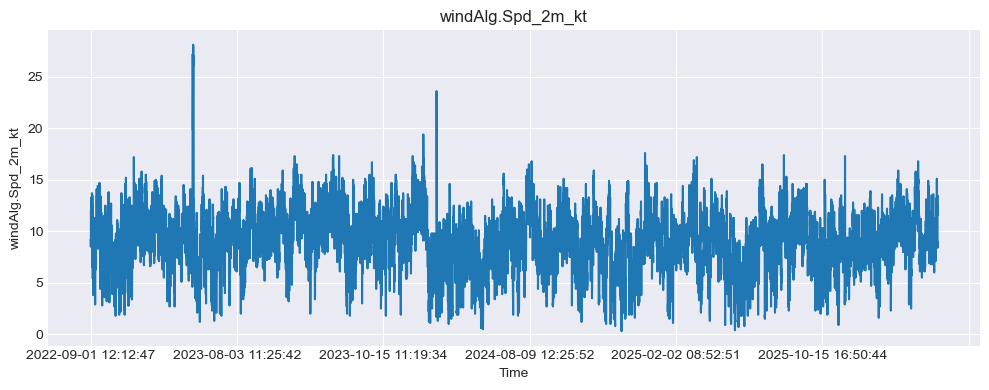

Parameter: windAlg.Dir_2m
Meaning : Wind direction at 2 m height in degrees (0–360). Shows where the wind is coming from near the surface.



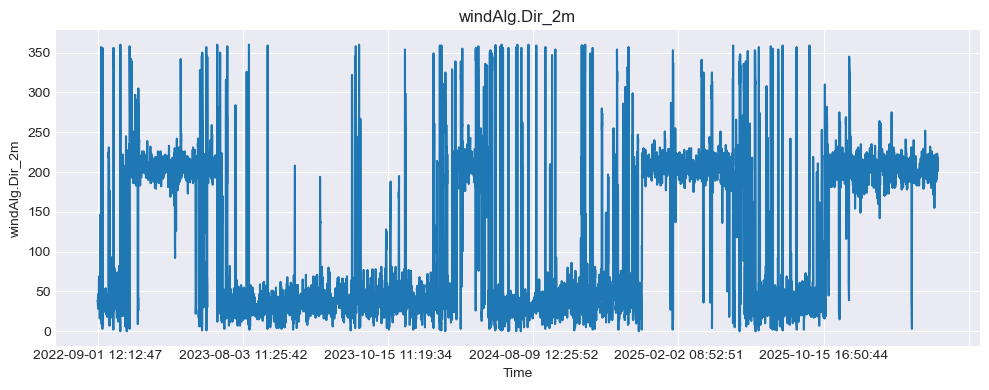

Parameter: windAlg.GustAv_10m_kt
Meaning : Average wind gust speed at 10 m height in knots. Highlights short, strong bursts of wind.



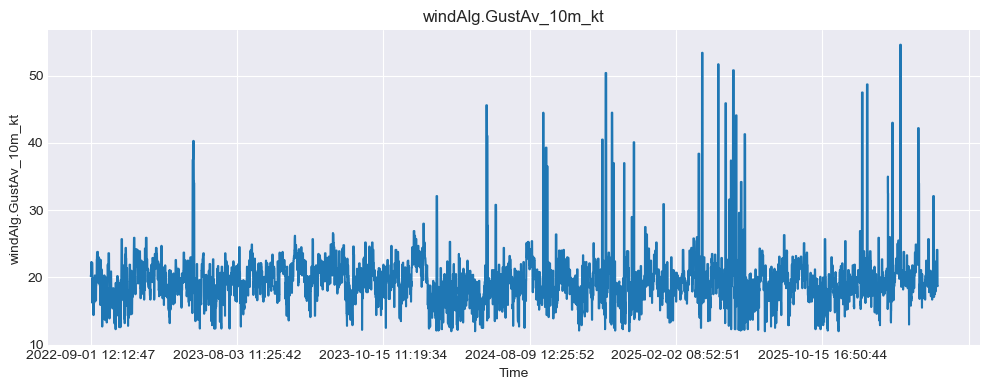

Parameter: windAlg.SpdX_2m_kt
Meaning : Maximum wind speed at 2 m in knots over the sampling interval.



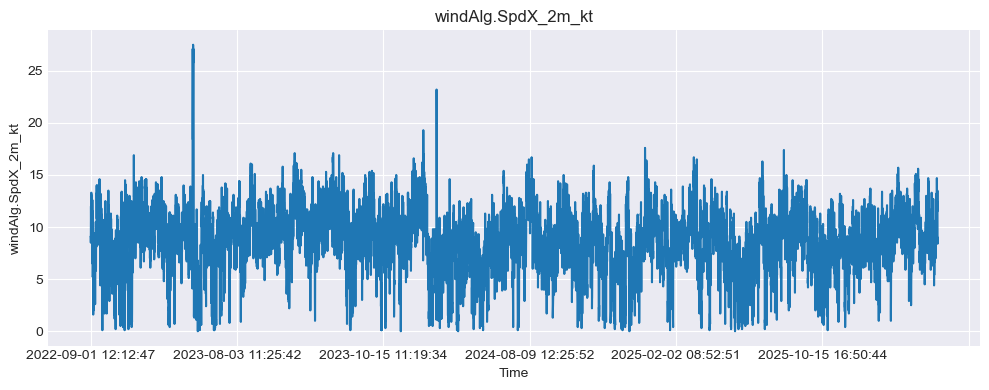

Parameter: windAlg.Spd_10m_kt
Meaning : Wind speed at 10 m height in knots. Common reference level for meteorological wind.



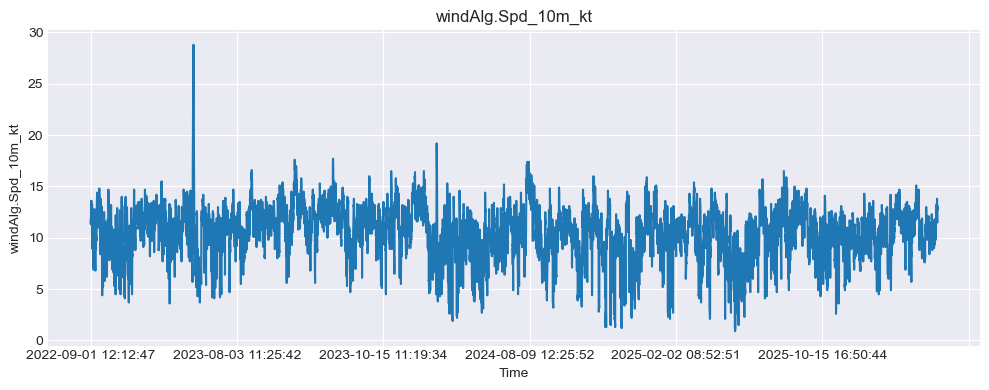

Parameter: windAlg.Dir_10m
Meaning : Wind direction at 10 m height in degrees. Used to study prevailing wind patterns.



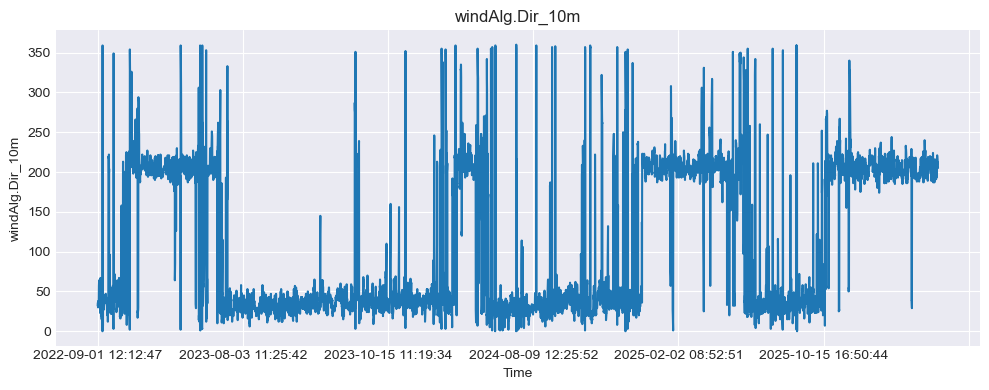

Parameter: windAlg.DirCCw_10m
Meaning : Counter-clockwise wind direction metric at 10 m (degrees). Useful for directional statistics.



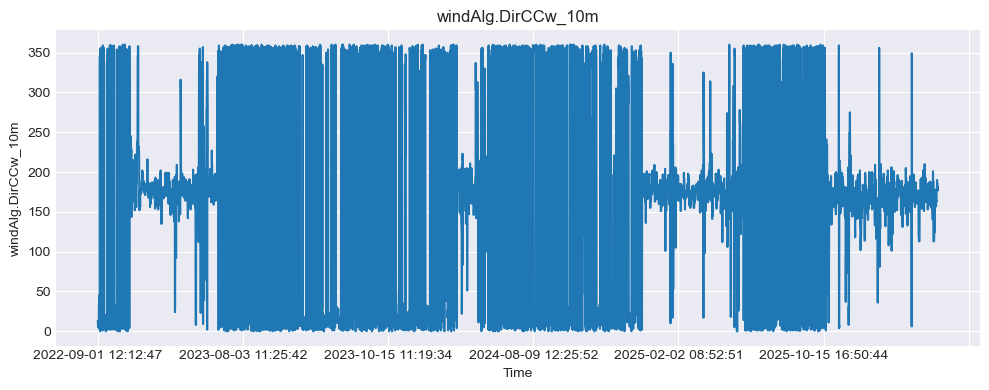

Parameter: windAlg.DirCw_10m
Meaning : Clockwise wind direction metric at 10 m (degrees). Complements DirCCw_10m.



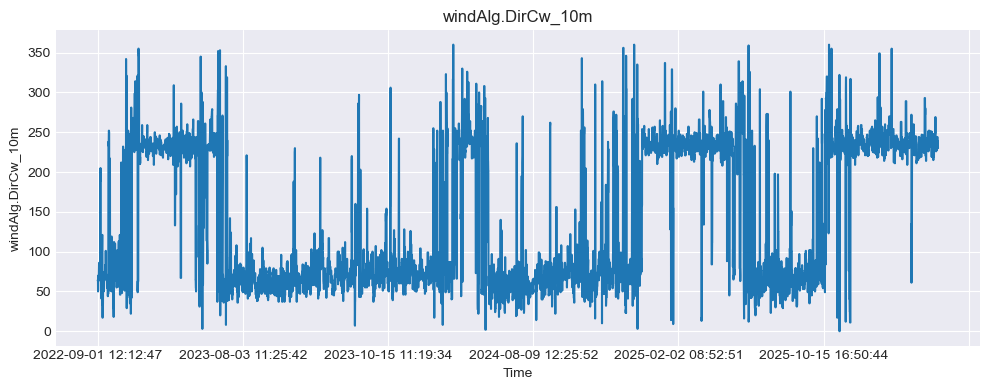

Parameter: windAlg.Peak_10m_kt
Meaning : Peak (maximum) wind speed at 10 m in knots within each interval.



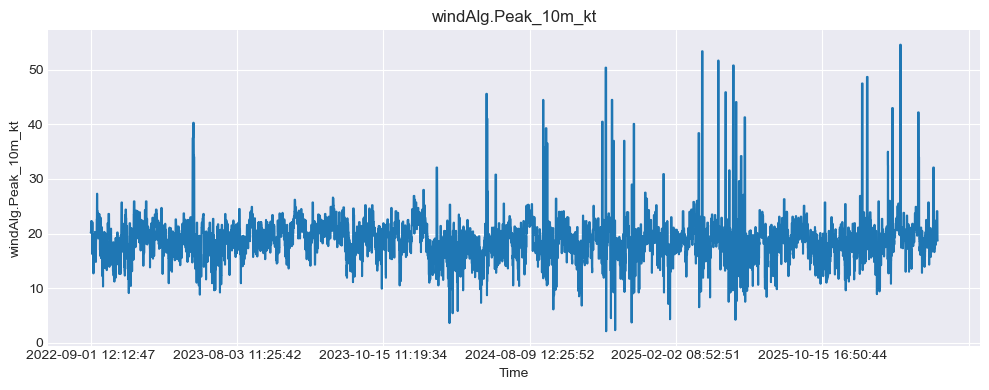

Parameter: zenoAlg.AT_5m_C
Meaning : Air temperature at 5 m in degrees Celsius. Shows heating/cooling over time.



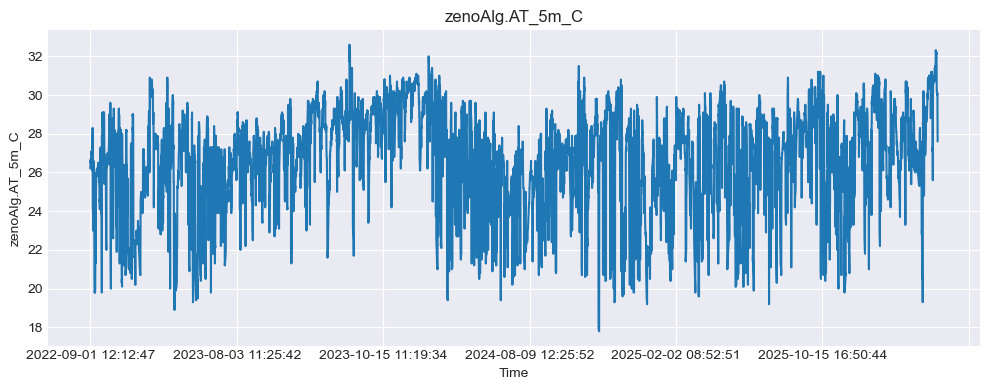

Parameter: zenoAlg.DP_5m_C
Meaning : Dew point temperature at 5 m in degrees Celsius. Closer to air temperature means higher humidity.



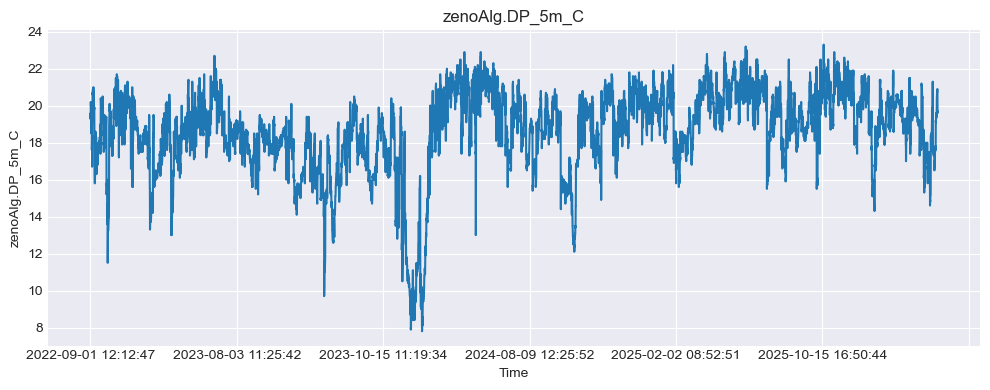

Parameter: zenoAlg.RH_5m
Meaning : Relative humidity at 5 m in percent. Near 100% indicates saturated, near 0% very dry air.



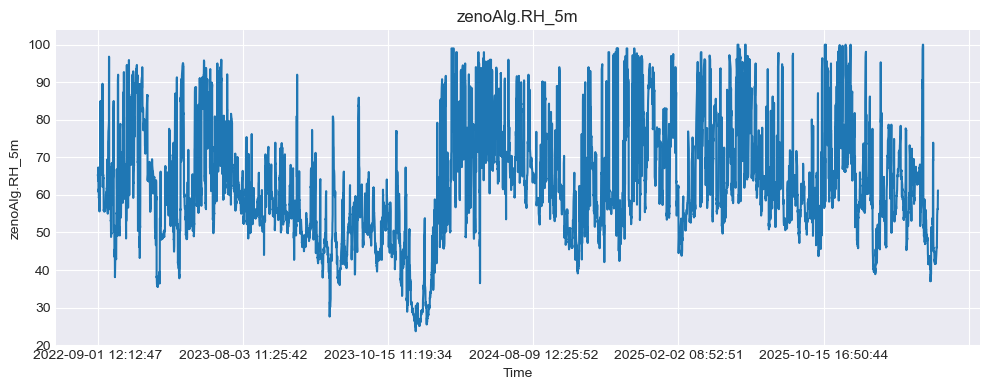

Parameter: SR_6m_J/mncm2
Meaning : Solar radiation at 6 m (energy per unit area). Higher midday values indicate strong sunlight.



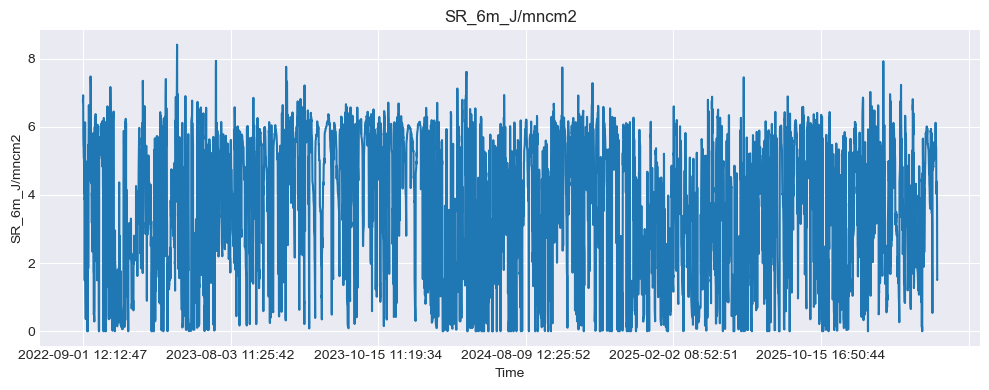

Parameter: baroAlg.QNH_1m_mb
Meaning : Sea-level adjusted pressure (QNH) in millibars. Used by aviation and for synoptic analysis.



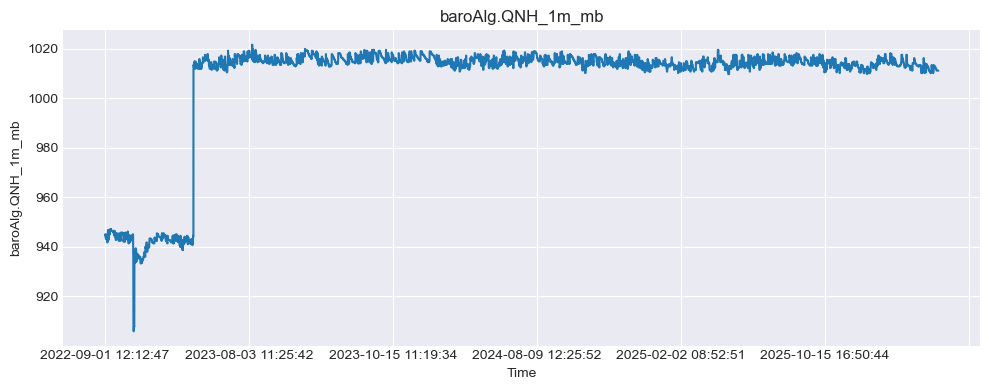

Parameter: baroAlg.QFE_1m_mb
Meaning : Station-level pressure (QFE) in millibars at the sensor site.



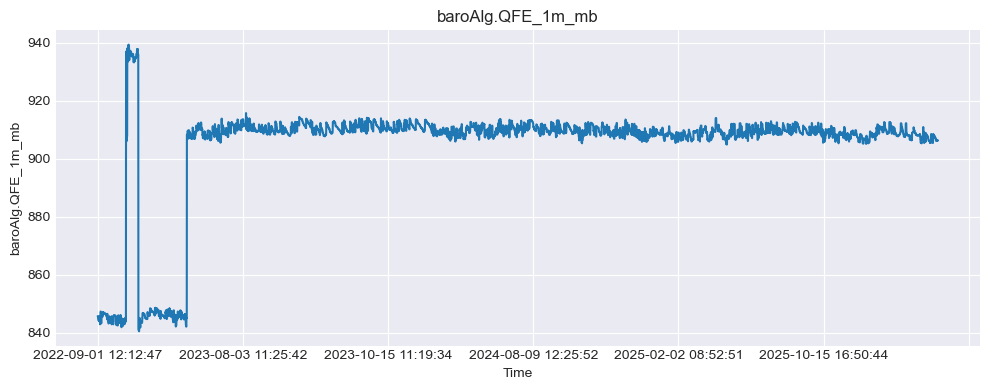

Parameter: baroAlg.BPLow_1m_mb
Meaning : Low-level barometric pressure in millibars; useful for tracking pressure systems.



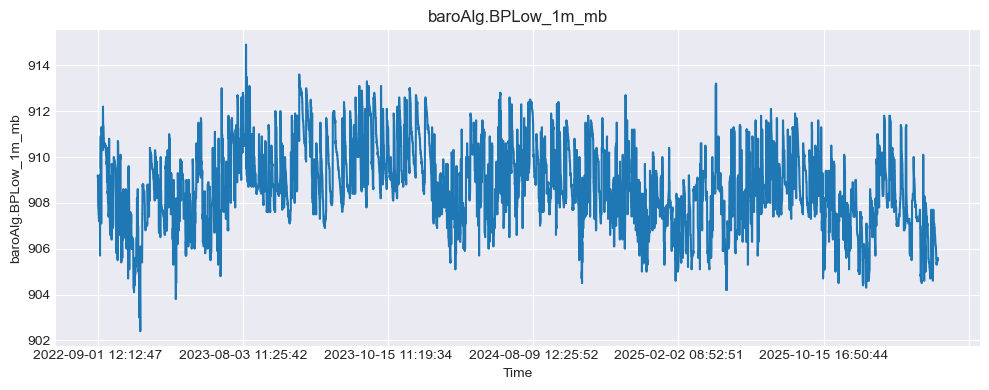

Parameter: zenoAlg.PP_1h_mm
Meaning : Precipitation accumulation over the last 1 hour in millimetres.



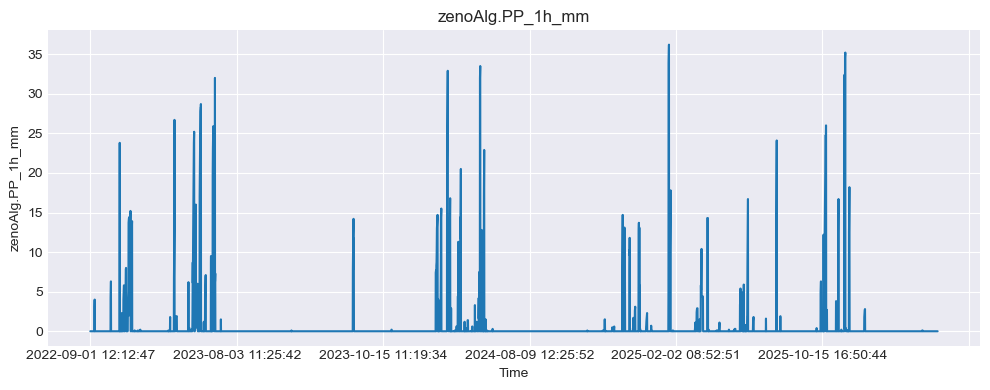

Parameter: zenoAlg.PP_6h_mm
Meaning : Precipitation accumulation over the last 6 hours in millimetres.



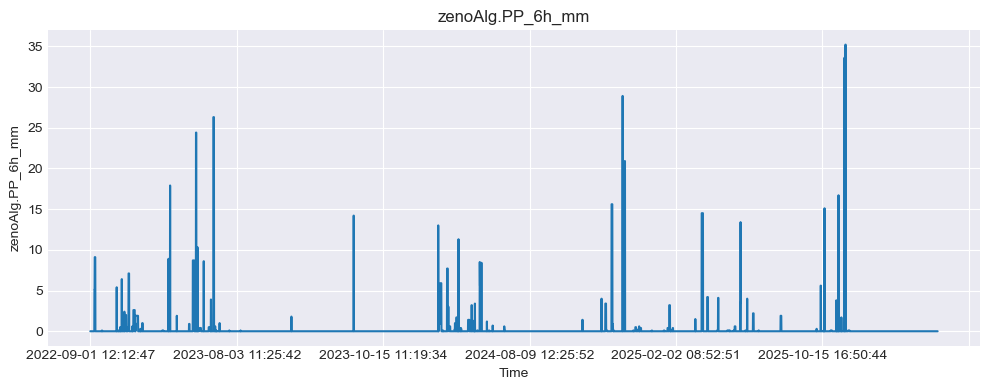

In [5]:
INTERPRETATIONS = {
    "windAlg.Spd_2m_kt": "Wind speed measured 2 m above ground in knots. Higher values mean stronger near-surface winds.",
    "windAlg.Dir_2m": "Wind direction at 2 m height in degrees (0–360). Shows where the wind is coming from near the surface.",
    "windAlg.GustAv_10m_kt": "Average wind gust speed at 10 m height in knots. Highlights short, strong bursts of wind.",
    "windAlg.SpdX_2m_kt": "Maximum wind speed at 2 m in knots over the sampling interval.",
    "windAlg.Spd_10m_kt": "Wind speed at 10 m height in knots. Common reference level for meteorological wind.",
    "windAlg.Dir_10m": "Wind direction at 10 m height in degrees. Used to study prevailing wind patterns.",
    "windAlg.DirCCw_10m": "Counter-clockwise wind direction metric at 10 m (degrees). Useful for directional statistics.",
    "windAlg.DirCw_10m": "Clockwise wind direction metric at 10 m (degrees). Complements DirCCw_10m.",
    "windAlg.Peak_10m_kt": "Peak (maximum) wind speed at 10 m in knots within each interval.",
    "zenoAlg.AT_5m_C": "Air temperature at 5 m in degrees Celsius. Shows heating/cooling over time.",
    "zenoAlg.DP_5m_C": "Dew point temperature at 5 m in degrees Celsius. Closer to air temperature means higher humidity.",
    "zenoAlg.RH_5m": "Relative humidity at 5 m in percent. Near 100% indicates saturated, near 0% very dry air.",
    "SR_6m_J/mncm2": "Solar radiation at 6 m (energy per unit area). Higher midday values indicate strong sunlight.",
    "baroAlg.QNH_1m_mb": "Sea-level adjusted pressure (QNH) in millibars. Used by aviation and for synoptic analysis.",
    "baroAlg.QFE_1m_mb": "Station-level pressure (QFE) in millibars at the sensor site.",
    "baroAlg.BPLow_1m_mb": "Low-level barometric pressure in millibars; useful for tracking pressure systems.",
    "zenoAlg.PP_1h_mm": "Precipitation accumulation over the last 1 hour in millimetres.",
    "zenoAlg.PP_6h_mm": "Precipitation accumulation over the last 6 hours in millimetres.",
}

for col in df.columns:
    print("=" * 80)
    print(f"Parameter: {col}")
    desc = INTERPRETATIONS.get(col, "No specific description available; inspect the units and range.")
    print("Meaning :", desc)
    print()

    # Ensure numeric series for plotting (handles string-typed numbers)
    series = pd.to_numeric(df[col], errors="coerce")
    if series.dropna().empty:
        print("Skipped: no numeric data to plot after conversion.")
        continue

    ax = series.plot(figsize=(10, 4))
    ax.set_title(col)
    ax.set_xlabel("Time")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()
